In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [89]:
def exact_solution(x, t, eps):
    return -np.tanh((x + 0.5 - t)/(2*eps)) + 1

def eta(x, eps):
    return exact_solution(x, 0, eps)

def gL(t, eps):
    return exact_solution(-1, t, eps)

def gR(t, eps):
    return exact_solution(1, t, eps)


def Burgers_FTBS_FTCS(eps, T, Nx, umax):

    xmin, xmax = -1.0, 1.0

    dx = (xmax - xmin)/Nx
    x = np.linspace(xmin, xmax, Nx+1)

    # stability conditions
    dt_adv =  dx / umax
    dt_diff = 0.5 * dx**2 / eps

    dt = 0.2 * min(dt_adv, dt_diff) # we ensure that we are well within the bounds

    Nt = int(np.ceil(T/dt))
    dt = T/Nt

    a = dt / dx
    d = eps * dt / dx**2
    

    u = np.zeros((Nt+1, Nx+1))

    # initial condition
    u[0,:] = eta(x, eps)

    for n in range(Nt):
        t = n*dt
        u[n,0]  = gL(t, eps)
        u[n,-1] = gR(t, eps)

        for j in range(1, Nx):
            advection = a * u[n,j] * (u[n,j] - u[n,j-1])
            diffusion = d * (u[n,j+1] - 2*u[n,j] + u[n,j-1])
            u[n+1,j] = (u[n,j] - advection + diffusion)

        # enforce BC at next step
        u[n+1,0]  = gL(t+dt, eps)
        u[n+1,-1] = gR(t+dt, eps)

    return u, dt, dx, x


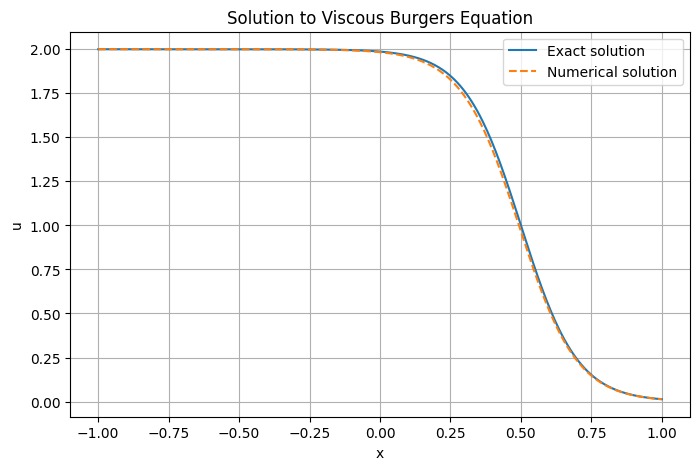

In [52]:
# Parameters
eps = 0.1
T = 1
Nx = 400
umax = 2

u, dt, dx, x = Burgers_FTBS_FTCS(eps, T, Nx, umax)

u_exact = exact_solution(x, T, eps)

# Plot
plt.figure(figsize=(8,5))

plt.plot(x, u_exact, label="Exact solution")
plt.plot(x, u[-1,:], "--", label="Numerical solution")


plt.xlabel("x")
plt.ylabel("u")
plt.title(f"Solution to Viscous Burgers Equation")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
Nx_values = [25, 50, 100,200, 400, 800]

dx_errors = []
dx_values = []

eps = 0.1
T = 1.0
umax = 2

for Nx in Nx_values:
    u, dt, dx, x = Burgers_FTBS_FTCS(eps, T, Nx, umax)

    # exact solution at final time
    u_ex = exact_solution(x, T, eps)

    error = np.max(np.abs(u[-1, :] - u_ex))

    dx_errors.append(error)
    dx_values.append(dx)

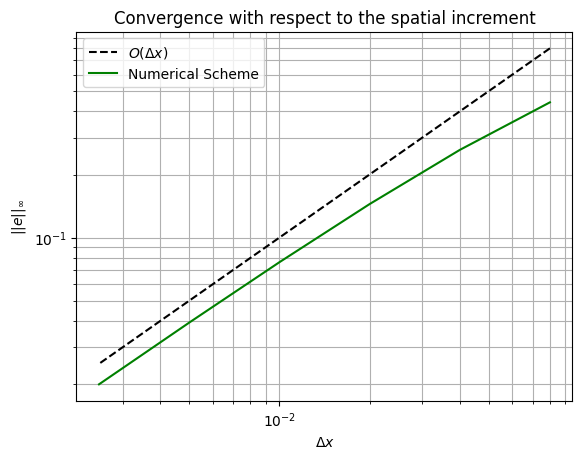

array([0.97784538, 1.94465013])

In [94]:
plt.loglog(dx_values,10*np.array(dx_values), 'k--', label=r"$O(\Delta x)$")
plt.loglog(dx_values,dx_errors,color="green", label=r"Numerical Scheme")
plt.title("Convergence with respect to the spatial increment")
plt.xlabel(r'$\Delta x$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dx_values[4:]),np.log(dx_errors[4:]),1)